# Sumativa 1: Análisis Exploratorio e Inferencia Estadística
**Magíster en Ciencia de Datos e Inteligencia Artificial - UNAB**
- **Integrantes:** Verónica Durán, Raúl Moya, Daniela Rojas, Manuel Sánchez
- **Grupo 2**
- **Curso:** MCDI501 - Estadística Computacional para la Toma de Decisiones
- **Dataset:** Online Shoppers Purchasing Intention



### Criterio metodológico de esta versión

Esta versión conserva los cálculos reproducibles de la exploración inicial y fortalece su interpretación estadística. La lectura de los resultados sigue la secuencia **contexto → tipo de variable → descripción → relación → inferencia → interpretación**, evitando atribuir causalidad a asociaciones observacionales.


## 1. Contexto y descripción del conjunto de datos

El conjunto de datos **Online Shoppers Purchasing Intention** contiene información de **12.330 sesiones** de navegación en un sitio de comercio electrónico. Combina variables relacionadas con páginas visitadas, duración de navegación, métricas de Google Analytics y características de la sesión.

La variable de resultado es **`Revenue`**, que indica si la sesión terminó (`True`) o no (`False`) en una compra.

**Fuente:** UCI Machine Learning Repository — *Online Shoppers Purchasing Intention Dataset*.

En esta etapa se conserva el archivo original sin modificaciones en `data/raw/`.


## 2. Importación de librerías


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## 3. Carga reproducible de los datos

El bloque siguiente permite ejecutar el notebook tanto desde la carpeta `notebooks/` como desde la raíz del repositorio.


In [2]:
# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


rutas_posibles = [
    Path("../data/raw/online_shoppers_intention.csv"),
    Path("data/raw/online_shoppers_intention.csv"),
]

ruta = next((p for p in rutas_posibles if p.exists()), None)

if ruta is None:
    raise FileNotFoundError(
        "No se encontró 'online_shoppers_intention.csv'. "
        "Verifique que esté en data/raw/."
    )

df = pd.read_csv(ruta)

print(f"Archivo cargado: {ruta.resolve()}")
print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
df.head()


Archivo cargado: /home/user/Estadistica_Computacional/data/raw/online_shoppers_intention.csv
Dimensiones: 12,330 filas x 18 columnas


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 4. Reconocimiento inicial de la base

Antes de calcular estadísticas se revisan dimensiones, nombres de columnas, tipos computacionales, valores faltantes, duplicados y categorías. Esta etapa permite verificar que la estructura del archivo corresponda con lo esperado y evita aplicar procedimientos estadísticos a variables mal clasificadas.


In [3]:
print("Dimensiones:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())


Dimensiones: (12330, 18)

Columnas:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [5]:
resumen_calidad = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_no_nulos": df.notna().sum(),
    "n_nulos": df.isna().sum(),
    "pct_nulos": (df.isna().mean() * 100).round(2),
    "n_unicos": df.nunique(dropna=False)
})

resumen_calidad


,dtype,n_no_nulos,n_nulos,pct_nulos,n_unicos
Administrative,int64,12330,0,0.0,27
Administrative_Duration,float64,12330,0,0.0,3335
Informational,int64,12330,0,0.0,17
Informational_Duration,float64,12330,0,0.0,1258
ProductRelated,int64,12330,0,0.0,311
ProductRelated_Duration,float64,12330,0,0.0,9551
BounceRates,float64,12330,0,0.0,1872
ExitRates,float64,12330,0,0.0,4777
PageValues,float64,12330,0,0.0,2704
SpecialDay,float64,12330,0,0.0,6


In [6]:
duplicados = df.duplicated().sum()

print(f"Filas duplicadas exactas: {duplicados}")
print(f"Porcentaje de duplicados: {duplicados / len(df) * 100:.2f}%")


Filas duplicadas exactas: 125
Porcentaje de duplicados: 1.01%


### Calidad de los datos y registros duplicados

El conjunto contiene **12.330 sesiones y 18 variables**, sin valores faltantes. Se identificaron **125 filas exactamente duplicadas (1,01 %)**. Estos registros se mantienen en este estado porque el dataset no dispone de un identificador único de sesión que permita demostrar que corresponden a errores de duplicación y no a sesiones distintas con iguales características observadas.

La decisión metodológica es, por tanto, **documentar los duplicados y no eliminarlos automáticamente**. Esto evita modificar observaciones potencialmente válidas sin evidencia suficiente.


## 5. Identificación y clasificación estadística de las variables

La clasificación estadística no depende únicamente del `dtype` de pandas. Por ejemplo, una variable almacenada como entero puede representar una categoría codificada y, por tanto, ser cualitativa nominal.

La siguiente tabla documenta la clasificación utilizada en el proyecto.


In [7]:
clasificacion = pd.DataFrame([
    ["Administrative", "Cuantitativa", "Discreta", "Número de páginas administrativas visitadas"],
    ["Administrative_Duration", "Cuantitativa", "Continua", "Tiempo dedicado a páginas administrativas"],
    ["Informational", "Cuantitativa", "Discreta", "Número de páginas informativas visitadas"],
    ["Informational_Duration", "Cuantitativa", "Continua", "Tiempo dedicado a páginas informativas"],
    ["ProductRelated", "Cuantitativa", "Discreta", "Número de páginas relacionadas con productos visitadas"],
    ["ProductRelated_Duration", "Cuantitativa", "Continua", "Tiempo dedicado a páginas de productos"],
    ["BounceRates", "Cuantitativa", "Continua", "Tasa de rebote"],
    ["ExitRates", "Cuantitativa", "Continua", "Tasa de salida"],
    ["PageValues", "Cuantitativa", "Continua", "Valor de página asociado a la sesión"],
    ["SpecialDay", "Cuantitativa", "Continua", "Cercanía de la sesión a una fecha especial"],
    ["Month", "Cualitativa", "Ordinal/temporal", "Mes de la sesión"],
    ["OperatingSystems", "Cualitativa", "Nominal", "Sistema operativo codificado"],
    ["Browser", "Cualitativa", "Nominal", "Navegador codificado"],
    ["Region", "Cualitativa", "Nominal", "Región codificada"],
    ["TrafficType", "Cualitativa", "Nominal", "Tipo/fuente de tráfico codificado"],
    ["VisitorType", "Cualitativa", "Nominal", "Tipo de visitante"],
    ["Weekend", "Cualitativa", "Nominal dicotómica", "Indica si la sesión ocurrió en fin de semana"],
    ["Revenue", "Cualitativa", "Nominal dicotómica", "Indica si la sesión terminó en compra"],
], columns=["Variable", "Naturaleza", "Tipo", "Descripción"])

clasificacion


,Variable,Naturaleza,Tipo,Descripción
0,Administrative,Cuantitativa,Discreta,Número de páginas administrativas visitadas
1,Administrative_Duration,Cuantitativa,Continua,Tiempo dedicado a páginas administrativas
2,Informational,Cuantitativa,Discreta,Número de páginas informativas visitadas
3,Informational_Duration,Cuantitativa,Continua,Tiempo dedicado a páginas informativas
4,ProductRelated,Cuantitativa,Discreta,Número de páginas relacionadas con productos v...
5,ProductRelated_Duration,Cuantitativa,Continua,Tiempo dedicado a páginas de productos
6,BounceRates,Cuantitativa,Continua,Tasa de rebote
7,ExitRates,Cuantitativa,Continua,Tasa de salida
8,PageValues,Cuantitativa,Continua,Valor de página asociado a la sesión
9,SpecialDay,Cuantitativa,Continua,Cercanía de la sesión a una fecha especial


### Interpretación de la clasificación de variables

La clasificación estadística se realiza según el **significado de cada variable**, no únicamente según el `dtype` asignado por pandas. Por ejemplo, `OperatingSystems`, `Browser`, `Region` y `TrafficType` aparecen codificadas con números, pero esos números representan categorías y no cantidades sobre las que tenga sentido calcular una media.

`Month` se considera una **variable cualitativa temporal/cíclica**: sus categorías representan meses y su interpretación está asociada a patrones temporales, pero no constituye una escala ordinal convencional de distancias comparables.

`SpecialDay` corresponde a un **índice numérico de proximidad a una fecha especial**. Aunque conceptualmente representa una magnitud de proximidad, en el dataset solo se observan valores discretizados. Esta particularidad se documenta para evitar interpretarlo como una variable continua ordinaria sin matices.

La variable objetivo `Revenue` es **cualitativa nominal dicotómica** (`True`/`False`) e indica si la sesión finalizó o no en una compra.


## 6. Estadística descriptiva

### 6.1 Variables cuantitativas

Para las variables cuantitativas se calculan medidas de tendencia central y dispersión. Se incluyen media y mediana porque una diferencia importante entre ambas puede sugerir asimetría. La desviación estándar y el rango intercuartílico permiten describir la dispersión.


In [8]:
variables_cuantitativas = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
]

resumen_num = df[variables_cuantitativas].describe().T
resumen_num["mediana"] = df[variables_cuantitativas].median()
resumen_num["varianza"] = df[variables_cuantitativas].var()
resumen_num["IQR"] = (
    df[variables_cuantitativas].quantile(0.75)
    - df[variables_cuantitativas].quantile(0.25)
)
resumen_num["CV_%"] = (
    df[variables_cuantitativas].std()
    / df[variables_cuantitativas].mean().replace(0, np.nan)
    * 100
)
resumen_num["asimetria"] = df[variables_cuantitativas].skew()
resumen_num["curtosis"] = df[variables_cuantitativas].kurt()

resumen_num.round(3)


,count,mean,std,min,25%,50%,75%,max,mediana,varianza,IQR,CV_%,asimetria,curtosis
Administrative,12330.0,2.315,3.322,0.0,0.000,1.000,4.000,27.000,1.000,11.034,4.000,143.479,1.960,4.701
Administrative_Duration,12330.0,80.819,176.779,0.0,0.000,7.500,93.256,3398.750,7.500,31250.853,93.256,218.736,5.616,50.557
Informational,12330.0,0.504,1.270,0.0,0.000,0.000,0.000,24.000,0.000,1.613,0.000,252.231,4.036,26.932
Informational_Duration,12330.0,34.472,140.749,0.0,0.000,0.000,0.000,2549.375,0.000,19810.364,0.000,408.296,7.579,76.317
ProductRelated,12330.0,31.731,44.476,0.0,7.000,18.000,38.000,705.000,18.000,1978.070,31.000,140.162,4.342,31.212
ProductRelated_Duration,12330.0,1194.746,1913.669,0.0,184.138,598.937,1464.157,63973.522,598.937,3662130.143,1280.020,160.174,7.263,137.174
BounceRates,12330.0,0.022,0.048,0.0,0.000,0.003,0.017,0.200,0.003,0.002,0.017,218.501,2.948,7.723
ExitRates,12330.0,0.043,0.049,0.0,0.014,0.025,0.050,0.200,0.025,0.002,0.036,112.824,2.149,4.017
PageValues,12330.0,5.889,18.568,0.0,0.000,0.000,0.000,361.764,0.000,344.787,0.000,315.293,6.383,65.636
SpecialDay,12330.0,0.061,0.199,0.0,0.000,0.000,0.000,1.000,0.000,0.040,0.000,323.825,3.303,9.914


### Interpretación de la estadística descriptiva

Las variables cuantitativas presentan, en general, **asimetría positiva**, con concentraciones importantes de valores bajos y una menor cantidad de observaciones elevadas. Esto se aprecia especialmente en variables de duración y en `PageValues`. En consecuencia, la media puede verse influida por valores altos, por lo que se interpreta conjuntamente con la **mediana y el rango intercuartílico (IQR)**.

Los coeficientes de variación son elevados en varias variables. Sin embargo, su interpretación debe realizarse con cautela cuando la media se encuentra próxima a cero, como ocurre en `BounceRates`, `ExitRates` y `SpecialDay`.

En `Revenue`, **1.908 de las 12.330 sesiones finalizaron en compra (15,47 %)**, mientras que 10.422 no lo hicieron (84,53 %). Por tanto, la variable objetivo presenta un **desbalance de clases**, aspecto relevante para análisis posteriores.


### 6.2 Variables cualitativas

Para las variables categóricas son más pertinentes las frecuencias y proporciones que la media.


In [9]:
variables_categoricas = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend",
    "Revenue",
]

for col in variables_categoricas:
    tabla = pd.DataFrame({
        "Frecuencia": df[col].value_counts(dropna=False),
        "Porcentaje": (df[col].value_counts(normalize=True, dropna=False) * 100).round(2)
    })
    print(f"\n--- {col} ---")
    print(tabla)



--- Month ---
       Frecuencia  Porcentaje
Month                        
May          3364       27.28
Nov          2998       24.31
Mar          1907       15.47
Dec          1727       14.01
Oct           549        4.45
Sep           448        3.63
Aug           433        3.51
Jul           432        3.50
June          288        2.34
Feb           184        1.49

--- OperatingSystems ---
                  Frecuencia  Porcentaje
OperatingSystems                        
2                       6601       53.54
1                       2585       20.97
3                       2555       20.72
4                        478        3.88
8                         79        0.64
6                         19        0.15
7                          7        0.06
5                          6        0.05

--- Browser ---
         Frecuencia  Porcentaje
Browser                        
2              7961       64.57
1              2462       19.97
4               736        5.97
5           

## 7. Distribución de la variable objetivo: Revenue

Antes de estudiar relaciones con otras variables se caracteriza el resultado principal. Esto también permite identificar si existe desbalance entre sesiones con compra y sin compra.


In [10]:
revenue_resumen = pd.DataFrame({
    "Frecuencia": df["Revenue"].value_counts(),
    "Porcentaje": (df["Revenue"].value_counts(normalize=True) * 100).round(2)
})
revenue_resumen


,Frecuencia,Porcentaje
Revenue,,
False,10422,84.53
True,1908,15.47


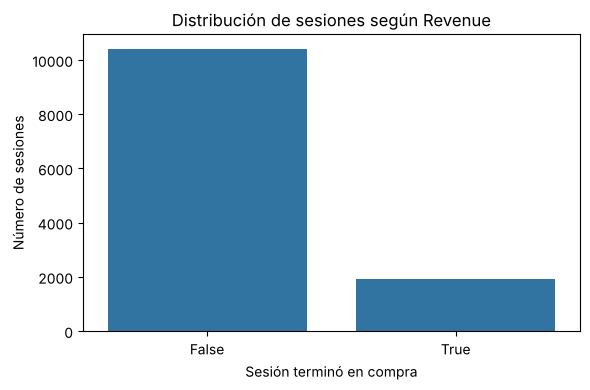

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Revenue")
plt.title("Distribución de sesiones según Revenue")
plt.xlabel("Sesión terminó en compra")
plt.ylabel("Número de sesiones")
plt.tight_layout()
plt.show()


### Interpretación de la variable objetivo `Revenue`

De las **12.330 sesiones** analizadas, **1.908 finalizaron en compra (15,47 %)**, mientras que **10.422 no finalizaron en compra (84,53 %)**. Esto evidencia un **desbalance de clases**, ya que la gran mayoría de las sesiones corresponde a la categoría sin compra.

Este resultado es relevante para la comprensión del problema y deberá considerarse en etapas posteriores del proyecto, especialmente si se desarrollan modelos predictivos. En esta etapa, se utiliza principalmente para caracterizar la distribución de la variable objetivo.

## 8. Visualización de variables cuantitativas

Se seleccionan variables especialmente relacionadas con el comportamiento de navegación. Los histogramas permiten observar forma, concentración y asimetría; los boxplots permiten comparar distribuciones según `Revenue`.


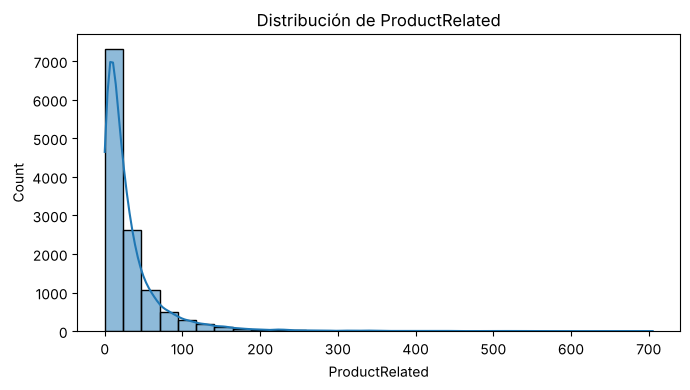

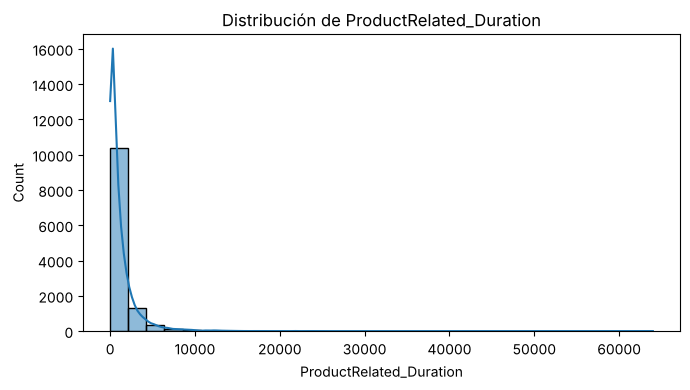

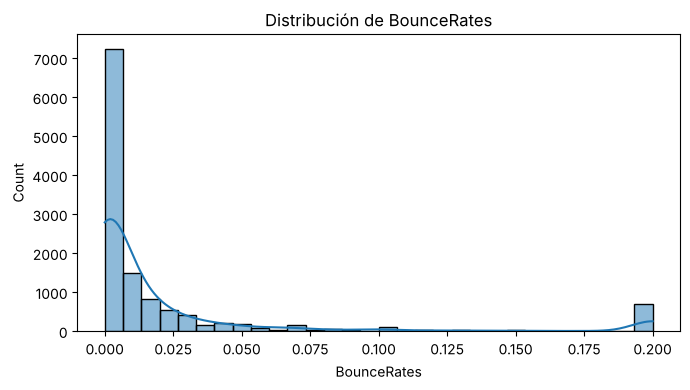

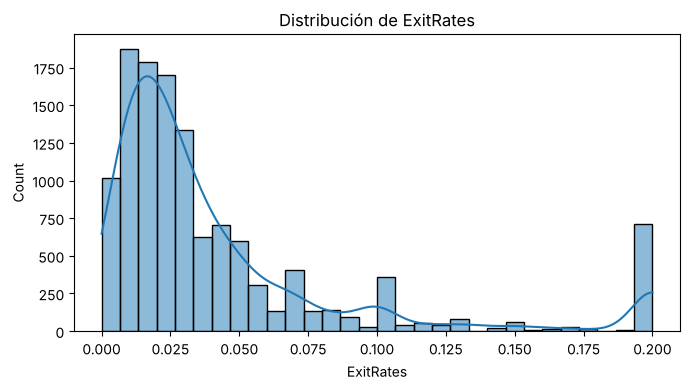

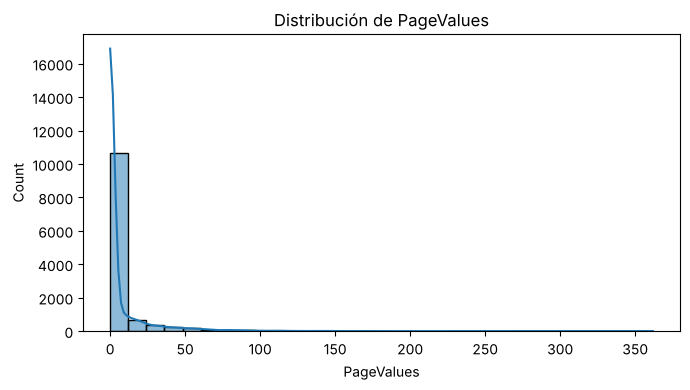

In [12]:
variables_graficos = [
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
]

for col in variables_graficos:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, bins=30, kde=True)
    plt.title(f"Distribución de {col}")
    plt.tight_layout()
    plt.show()


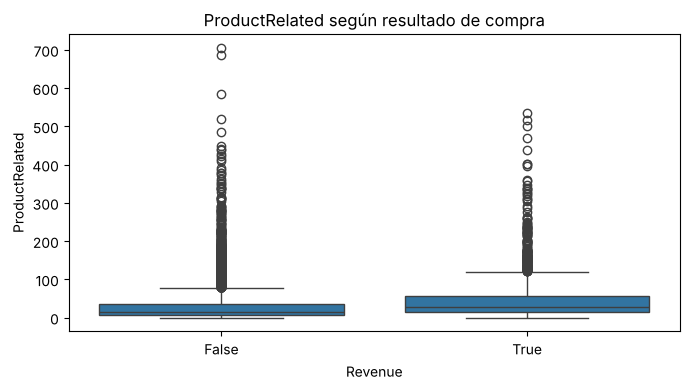

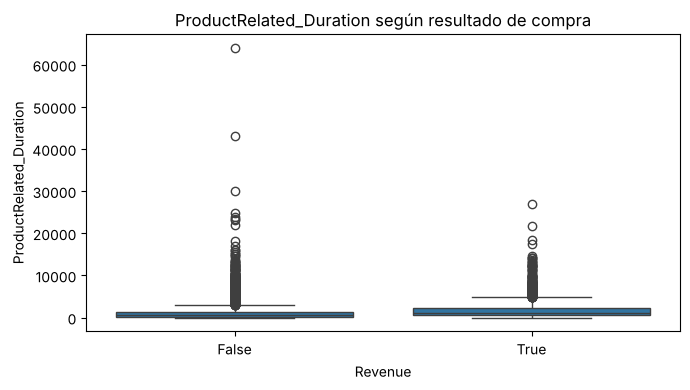

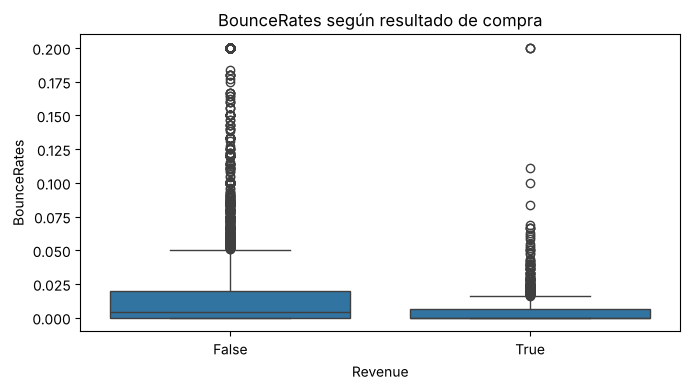

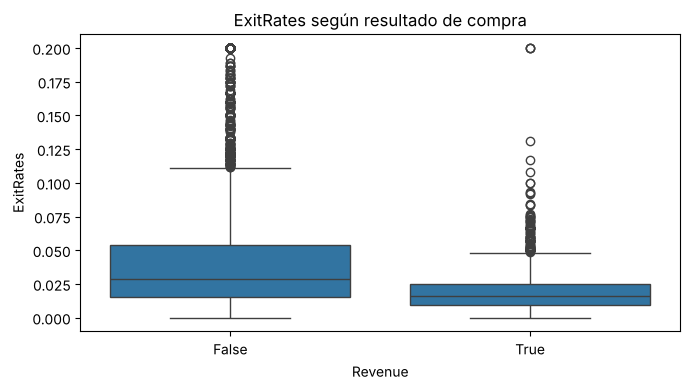

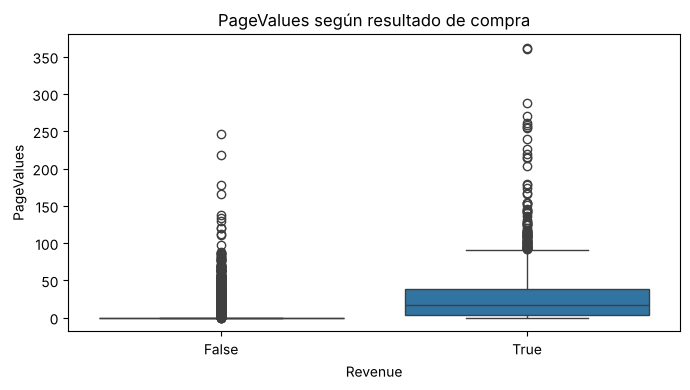

In [13]:
for col in variables_graficos:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="Revenue", y=col)
    plt.title(f"{col} según resultado de compra")
    plt.xlabel("Revenue")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


## 9. Relaciones preliminares entre variables

### 9.1 Relación entre variables cuantitativas

La matriz de correlación permite identificar asociaciones lineales entre variables cuantitativas. Una correlación alta no implica causalidad y también puede advertir que dos variables contienen información similar.


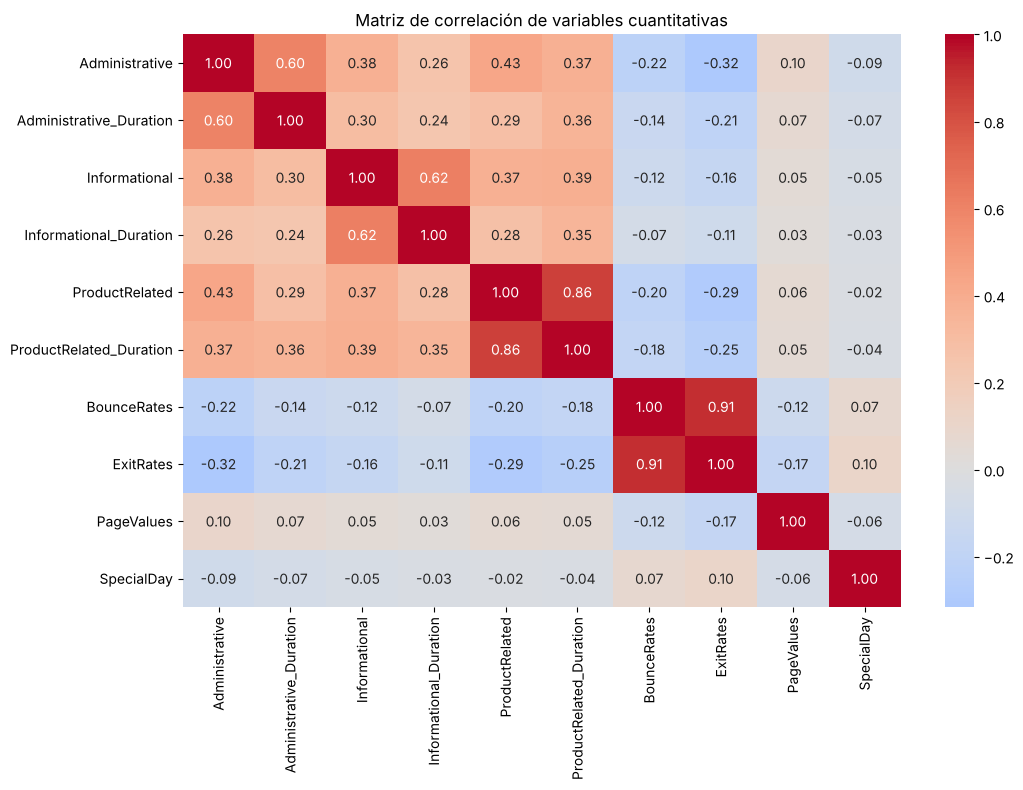

In [14]:
corr = df[variables_cuantitativas].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación de variables cuantitativas")
plt.tight_layout()
plt.show()


In [15]:
pares_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(key=abs, ascending=False)
        .rename("correlacion")
        .reset_index()
        .rename(columns={"level_0": "Variable_1", "level_1": "Variable_2"})
)

pares_corr.head(10)


,Variable_1,Variable_2,correlacion
0,BounceRates,ExitRates,0.913004
1,ProductRelated,ProductRelated_Duration,0.860927
2,Informational,Informational_Duration,0.618955
3,Administrative,Administrative_Duration,0.601583
4,Administrative,ProductRelated,0.431119
5,Informational,ProductRelated_Duration,0.387505
6,Administrative,Informational,0.376850
7,Informational,ProductRelated,0.374164
8,Administrative,ProductRelated_Duration,0.373939
9,Administrative_Duration,ProductRelated_Duration,0.355422


### 9.2 Variables categóricas y Revenue

Las tablas de contingencia permiten comparar la proporción de compra entre categorías. A continuación se exploran `VisitorType`, `Weekend` y `Month`.


In [16]:
for col in ["VisitorType", "Weekend", "Month"]:
    tabla = pd.crosstab(df[col], df["Revenue"], margins=True)
    print(f"\nTabla de contingencia: {col} vs Revenue")
    print(tabla)

    prop = pd.crosstab(df[col], df["Revenue"], normalize="index") * 100
    print("\nPorcentajes por categoría:")
    print(prop.round(2))



Tabla de contingencia: VisitorType vs Revenue
Revenue            False  True    All
VisitorType                          
New_Visitor         1272   422   1694
Other                 69    16     85
Returning_Visitor   9081  1470  10551
All                10422  1908  12330

Porcentajes por categoría:
Revenue            False  True 
VisitorType                    
New_Visitor        75.09  24.91
Other              81.18  18.82
Returning_Visitor  86.07  13.93

Tabla de contingencia: Weekend vs Revenue
Revenue  False  True    All
Weekend                    
False     8053  1409   9462
True      2369   499   2868
All      10422  1908  12330

Porcentajes por categoría:
Revenue  False  True 
Weekend              
False    85.11  14.89
True     82.60  17.40

Tabla de contingencia: Month vs Revenue
Revenue  False  True    All
Month                      
Aug        357    76    433
Dec       1511   216   1727
Feb        181     3    184
Jul        366    66    432
June       259    29    288
M

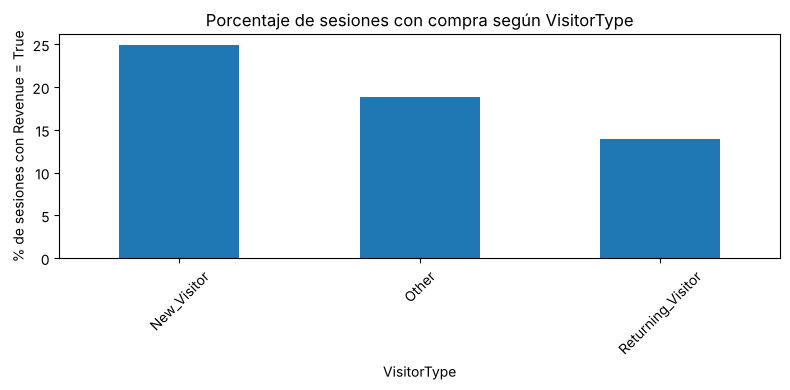

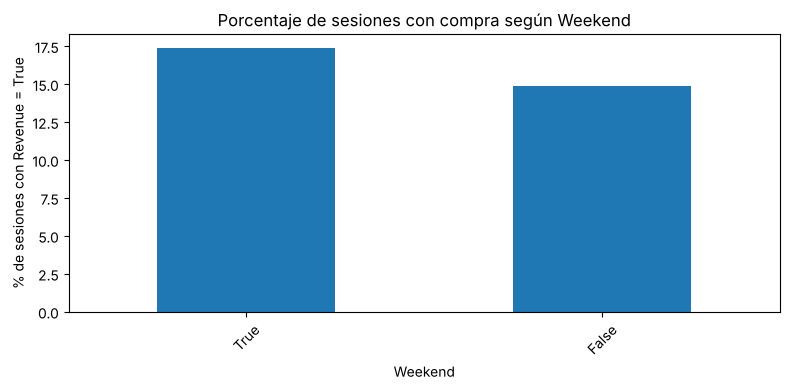

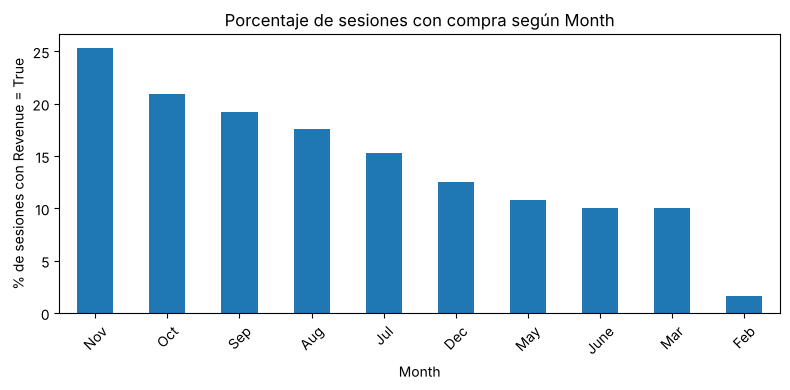

In [17]:
for col in ["VisitorType", "Weekend", "Month"]:
    prop_compra = (
        df.groupby(col, observed=False)["Revenue"]
          .mean()
          .mul(100)
          .sort_values(ascending=False)
    )

    plt.figure(figsize=(8, 4))
    prop_compra.plot(kind="bar")
    plt.title(f"Porcentaje de sesiones con compra según {col}")
    plt.ylabel("% de sesiones con Revenue = True")
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## 10. Estimación de parámetros

En esta sección se estiman parámetros poblacionales a partir de la muestra de 12.330 sesiones:

- **10.1** la proporción de sesiones que terminan en compra (`Revenue`);
- **10.2** la media poblacional de tres variables numéricas relevantes para el problema: `ProductRelated_Duration`, `PageValues` y `ExitRates`.

### 10.1 Proporción de sesiones con compra

La estimación puntual es la proporción observada de `Revenue = True`. Se construye además un intervalo de confianza del 95 % para esa proporción mediante la aproximación normal.

In [18]:
n = len(df)
x = df["Revenue"].astype(bool).sum()
p_hat = x / n

z = stats.norm.ppf(0.975)
se = np.sqrt(p_hat * (1 - p_hat) / n)

li = max(0, p_hat - z * se)
ls = min(1, p_hat + z * se)

print(f"Número de sesiones: {n:,}")
print(f"Sesiones con compra: {x:,}")
print(f"Estimación puntual de la proporción de compra: {p_hat:.4f} ({p_hat*100:.2f}%)")
print(f"IC 95% para la proporción: [{li:.4f}, {ls:.4f}]")
print(f"IC 95% en porcentaje: [{li*100:.2f}%, {ls*100:.2f}%]")


Número de sesiones: 12,330
Sesiones con compra: 1,908
Estimación puntual de la proporción de compra: 0.1547 (15.47%)
IC 95% para la proporción: [0.1484, 0.1611]
IC 95% en porcentaje: [14.84%, 16.11%]


#### Interpretación de la proporción de compra

La proporción muestral de sesiones que finalizan en compra es:

**p̂ = 1.908 / 12.330 = 0,1547 (15,47 %).**

El intervalo de confianza del 95 % obtenido mediante aproximación normal es **[14,84 %, 16,11 %]**. Las condiciones de aproximación son ampliamente satisfechas, ya que tanto el número de compras como el de no compras son muy superiores a 10.

En términos frecuentistas, el procedimiento utilizado produciría intervalos que contienen la verdadera proporción poblacional aproximadamente en el 95 % de muestras repetidas bajo condiciones equivalentes. Para este conjunto de datos, el intervalo obtenido entrega un rango plausible para la tasa poblacional de conversión.

### 10.2 Media de variables numéricas relevantes

Se seleccionan tres variables numéricas por su vínculo directo con el comportamiento de compra:

| Variable | Qué mide | Por qué es relevante |
| --- | --- | --- |
| `ProductRelated_Duration` | Tiempo (segundos) en páginas de producto | Intensidad de la exploración de productos |
| `PageValues` | Valor promedio de las páginas visitadas antes de una transacción | Métrica de Google Analytics ligada a la conversión |
| `ExitRates` | Tasa de salida promedio de las páginas visitadas | Indicador de abandono de la sesión |

**Método.** Para cada variable se calcula la media muestral como estimador puntual y un **IC 95 % basado en la distribución t de Student**:

$$\bar{x} \pm t_{0,975;\,n-1}\,\frac{s}{\sqrt{n}}$$

Las tres variables presentan **fuerte asimetría positiva** (sección 8), por lo que no son normales. El intervalo t sigue siendo válido aproximadamente gracias al **Teorema Central del Límite**, dado el gran tamaño muestral (n = 12.330). Como verificación de robustez se calcula además un **IC 95 % bootstrap percentil** (5.000 remuestreos, semilla fija), que no supone normalidad.

In [19]:
variables_ic = ["ProductRelated_Duration", "PageValues", "ExitRates"]
B = 5000
rng = np.random.default_rng(RANDOM_STATE)

filas_ic = []
for col in variables_ic:
    x = df[col].to_numpy()
    n_x = len(x)
    media = x.mean()
    s = x.std(ddof=1)
    error_est = s / np.sqrt(n_x)
    t_crit = stats.t.ppf(0.975, df=n_x - 1)

    medias_boot = np.array([rng.choice(x, size=n_x, replace=True).mean() for _ in range(B)])
    boot_li, boot_ls = np.percentile(medias_boot, [2.5, 97.5])

    filas_ic.append({
        "variable": col,
        "n": n_x,
        "media": media,
        "desv_est": s,
        "error_est": error_est,
        "IC95_t_inf": media - t_crit * error_est,
        "IC95_t_sup": media + t_crit * error_est,
        "IC95_boot_inf": boot_li,
        "IC95_boot_sup": boot_ls,
        "mediana": np.median(x),
        "asimetria": stats.skew(x),
        "pct_ceros": (x == 0).mean() * 100,
    })

tabla_ic = pd.DataFrame(filas_ic).set_index("variable").round(4)
tabla_ic

,n,media,desv_est,error_est,IC95_t_inf,IC95_t_sup,IC95_boot_inf,IC95_boot_sup,mediana,asimetria,pct_ceros
variable,,,,,,,,,,,
ProductRelated_Duration,12330,1194.7462,1913.6693,17.2340,1160.9649,1228.5275,1161.0880,1229.0352,598.9369,7.2623,6.1233
PageValues,12330,5.8893,18.5684,0.1672,5.5615,6.2170,5.5724,6.2234,0.0000,6.3822,77.8589
ExitRates,12330,0.0431,0.0486,0.0004,0.0422,0.0439,0.0422,0.0440,0.0252,2.1485,0.6164


#### Interpretación de los intervalos

| Variable | Media (estimación puntual) | IC 95 % (t) | IC 95 % (bootstrap) |
| --- | --- | --- | --- |
| `ProductRelated_Duration` | 1.194,75 s (≈ 19,9 min) | [1.160,96 ; 1.228,53] | [1.161,09 ; 1.229,04] |
| `PageValues` | 5,889 | [5,562 ; 6,217] | [5,572 ; 6,223] |
| `ExitRates` | 0,0431 (4,31 %) | [0,0422 ; 0,0439] | [0,0422 ; 0,0440] |

- **`ProductRelated_Duration`:** con un 95 % de confianza, el tiempo medio que una sesión dedica a páginas de producto se encuentra entre **1.161 y 1.229 segundos** (aprox. 19,3 a 20,5 minutos).
- **`PageValues`:** el valor medio de página por sesión se ubica entre **5,56 y 6,22**. Sin embargo, la mediana es **0** y el **77,9 %** de las sesiones registra valor cero: la media está impulsada por una minoría de sesiones con valores altos.
- **`ExitRates`:** la tasa de salida media está entre **4,22 % y 4,39 %**, un intervalo muy estrecho que refleja baja variabilidad relativa y gran tamaño muestral.

**Justificación y consistencia.** En las tres variables los intervalos t y bootstrap prácticamente coinciden, lo que confirma que, con n = 12.330, la aproximación del Teorema Central del Límite es adecuada pese a la asimetría.

**Limitaciones.**
1. La media no es una medida representativa de la sesión "típica" cuando la distribución es muy asimétrica (especialmente en `PageValues`); por ello se reporta también la mediana.
2. Los intervalos suponen observaciones independientes. El dataset no identifica usuarios, por lo que varias sesiones podrían pertenecer a la misma persona, y existen 125 filas duplicadas que se mantuvieron (sección 4).
3. Los intervalos son muy estrechos por el gran n: indican precisión de la estimación, no relevancia práctica de los valores.

## 11. Pruebas de hipótesis

Se realizan dos pruebas pertinentes al problema, ambas con nivel de significancia **α = 0,05**. Se elige α = 0,05 porque es el estándar en análisis exploratorio y, en este contexto, un falso positivo (declarar una asociación inexistente) solo orientaría análisis posteriores, sin consecuencias operativas inmediatas.

### 11.1 Prueba 1: VisitorType y Revenue (chi-cuadrado de independencia)

Se evaluará si existe asociación estadística entre el **tipo de visitante (`VisitorType`)** y el resultado de compra (`Revenue`).

#### Hipótesis

- **H₀:** `VisitorType` y `Revenue` son independientes; no existe asociación estadística entre ambas variables.
- **H₁:** `VisitorType` y `Revenue` no son independientes; existe asociación estadística entre ambas variables.

Se utiliza una **prueba chi-cuadrado de independencia**, apropiada para analizar la relación entre dos variables categóricas. Supuestos: observaciones independientes y frecuencias esperadas ≥ 5 en todas las celdas (se verifica más abajo).

In [20]:
tabla_contingencia = pd.crosstab(df["VisitorType"], df["Revenue"])
tabla_contingencia


Revenue,False,True
VisitorType,,
New_Visitor,1272,422
Other,69,16
Returning_Visitor,9081,1470


In [21]:
chi2, p_valor, gl, esperadas = stats.chi2_contingency(tabla_contingencia)

esperadas_df = pd.DataFrame(
    esperadas,
    index=tabla_contingencia.index,
    columns=tabla_contingencia.columns
)

print(f"Chi-cuadrado: {chi2:.4f}")
print(f"Grados de libertad: {gl}")
print(f"p-valor: {p_valor:.6g}")
print(f"Frecuencia esperada mínima: {esperadas.min():.2f}")

alpha = 0.05

if p_valor < alpha:
    print("\nDecisión: se rechaza H₀ al nivel de significancia del 5%.")
    print("Existe evidencia estadística de asociación entre VisitorType y Revenue.")
else:
    print("\nDecisión: no se rechaza H₀ al nivel de significancia del 5%.")
    print("No se dispone de evidencia suficiente para afirmar una asociación entre VisitorType y Revenue.")

esperadas_df


Chi-cuadrado: 135.2519
Grados de libertad: 2
p-valor: 4.2699e-30
Frecuencia esperada mínima: 13.15

Decisión: se rechaza H₀ al nivel de significancia del 5%.
Existe evidencia estadística de asociación entre VisitorType y Revenue.


Revenue,False,True
VisitorType,,
New_Visitor,1431.862774,262.137226
Other,71.846715,13.153285
Returning_Visitor,8918.290511,1632.709489


### Interpretación de la prueba chi-cuadrado

Con un nivel de significancia de **α = 0,05**, se rechaza la hipótesis nula de independencia, ya que **p < 0,001**. Por lo tanto, existe evidencia estadísticamente significativa de **asociación entre el tipo de visitante (`VisitorType`) y la realización de una compra (`Revenue`)**.

Además, la frecuencia esperada mínima es **13,15**, superior a 5, por lo que se satisface esta condición de aplicación de la prueba chi-cuadrado. Descriptivamente, los visitantes nuevos presentan una proporción de compra de **24,91 %**, mientras que los visitantes recurrentes presentan una proporción de **13,93 %**.

Este resultado indica asociación estadística, pero no permite establecer una relación causal.

### 11.2 Tamaño del efecto de la prueba 1: V de Cramér

Un p-valor permite evaluar evidencia contra la hipótesis nula, pero no informa por sí solo la **magnitud** de la asociación. Por ello se calcula V de Cramér.

In [22]:
n_chi = tabla_contingencia.to_numpy().sum()
r, k = tabla_contingencia.shape

v_cramer = np.sqrt(chi2 / (n_chi * min(r - 1, k - 1)))

print(f"V de Cramér: {v_cramer:.4f}")


V de Cramér: 0.1047


### Interpretación del tamaño de efecto

El **V de Cramér = 0,105** indica que, aunque la asociación entre `VisitorType` y `Revenue` es estadísticamente significativa, su **magnitud es baja**. Por tanto, el tipo de visitante aporta información sobre la ocurrencia de compra, pero no debe interpretarse como un factor fuertemente asociado por sí solo.

### 11.3 Prueba 2: PageValues según Revenue

La sección 8 mostró que `PageValues` parece diferenciar fuertemente las sesiones con y sin compra. Se evalúa si esa diferencia es estadísticamente significativa.

#### Hipótesis

- **H₀:** la distribución de `PageValues` es la misma en sesiones con compra y sin compra.
- **H₁:** la distribución de `PageValues` difiere entre sesiones con compra y sin compra (prueba bilateral).

Primero se describen ambos grupos y luego se verifican los supuestos para elegir la prueba adecuada.

In [23]:
comparacion_pagevalues = (
    df.groupby("Revenue")["PageValues"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(3)
)

comparacion_pagevalues


,count,mean,median,std,min,max
Revenue,,,,,,
False,10422,1.976,0.000,9.072,0.0,246.759
True,1908,27.265,16.758,35.192,0.0,361.764


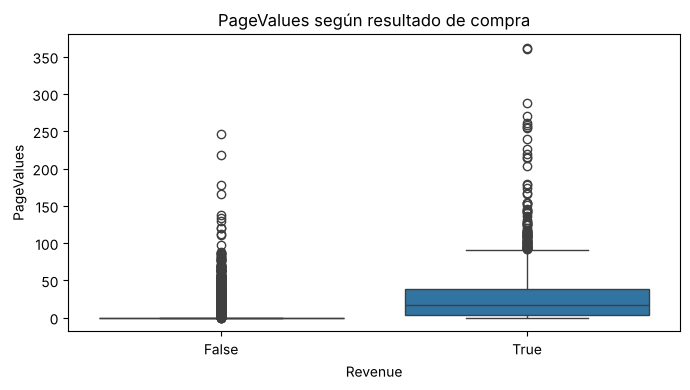

In [24]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="Revenue", y="PageValues")
plt.title("PageValues según resultado de compra")
plt.xlabel("Revenue")
plt.ylabel("PageValues")
plt.tight_layout()
plt.show()


In [25]:
def formato_p(p):
    return f"{p:.3g}" if p > 0 else "< 1e-300"


pv_compra = df.loc[df["Revenue"], "PageValues"]
pv_sin_compra = df.loc[~df["Revenue"], "PageValues"]

# Normalidad (D'Agostino-Pearson) en cada grupo
for nombre, grupo in [("Con compra", pv_compra), ("Sin compra", pv_sin_compra)]:
    est, p = stats.normaltest(grupo)
    print(f"Normalidad {nombre:<10} (n={len(grupo):>5}): estadístico = {est:,.1f}, p-valor = {formato_p(p)}")

# Homogeneidad de varianzas (Levene)
lev_est, lev_p = stats.levene(pv_compra, pv_sin_compra)
print(f"\nLevene: estadístico = {lev_est:,.1f}, p-valor = {formato_p(lev_p)}")

Normalidad Con compra (n= 1908): estadístico = 1,397.6, p-valor = 3.34e-304


Normalidad Sin compra (n=10422): estadístico = 15,957.5, p-valor = < 1e-300

Levene: estadístico = 3,224.2, p-valor = < 1e-300


#### Verificación de supuestos y elección de la prueba

- **Normalidad:** se rechaza en ambos grupos (p < 0,001). Además, el 77,9 % de las sesiones tiene `PageValues = 0`, por lo que la distribución está lejos de ser normal.
- **Homogeneidad de varianzas:** la prueba de Levene la rechaza (p < 0,001).
- **Independencia:** se asume que cada sesión es una observación independiente (con la limitación ya señalada sobre usuarios y duplicados).

Por estas razones se utiliza la prueba **U de Mann-Whitney**, no paramétrica, que compara las distribuciones de ambos grupos sin suponer normalidad. Como **tamaño del efecto** se reporta la **correlación biserial por rangos** (r_rb, entre −1 y 1). Como análisis de sensibilidad se reporta también la **prueba t de Welch**, que no supone varianzas iguales.

In [26]:
u_est, p_mw = stats.mannwhitneyu(pv_compra, pv_sin_compra, alternative="two-sided")
n1, n2 = len(pv_compra), len(pv_sin_compra)
r_rb = 2 * u_est / (n1 * n2) - 1

welch = stats.ttest_ind(pv_compra, pv_sin_compra, equal_var=False)

print(f"U de Mann-Whitney: U = {u_est:,.0f}, p-valor = {formato_p(p_mw)}")
print(f"Correlación biserial por rangos: r_rb = {r_rb:.3f}")
print(f"\nSensibilidad - t de Welch: t = {welch.statistic:.2f}, gl = {welch.df:.1f}, p-valor = {formato_p(welch.pvalue)}")

if p_mw < alpha:
    print("\nDecisión: se rechaza H₀ al nivel de significancia del 5%.")
else:
    print("\nDecisión: no se rechaza H₀ al nivel de significancia del 5%.")

U de Mann-Whitney: U = 17,166,757, p-valor = < 1e-300
Correlación biserial por rangos: r_rb = 0.727

Sensibilidad - t de Welch: t = 31.20, gl = 1953.6, p-valor = 9.61e-174

Decisión: se rechaza H₀ al nivel de significancia del 5%.


#### Interpretación de la prueba de Mann-Whitney

Con **α = 0,05** se **rechaza H₀** (p < 0,001): existe evidencia estadísticamente significativa de que la distribución de `PageValues` **difiere entre sesiones con y sin compra**. La prueba t de Welch conduce a la misma conclusión (t = 31,20; gl ≈ 1.954; p < 0,001).

A diferencia de la prueba 1, aquí el **tamaño del efecto es grande**: r_rb = **0,727**, lo que significa que, al tomar al azar una sesión con compra y una sin compra, la sesión con compra tiene `PageValues` mayor con mucha más frecuencia que a la inversa. Descriptivamente, la mediana es **16,76** en sesiones con compra frente a **0** en sesiones sin compra.

**Implicancia práctica:** `PageValues` es la variable con mayor capacidad de discriminación observada hasta ahora y es una candidata prioritaria para los modelos predictivos de las siguientes evaluaciones. Debe considerarse, sin embargo, que `PageValues` se calcula a partir de páginas visitadas antes de una transacción, por lo que parte de su relación con `Revenue` puede ser **mecánica** (posible fuga de información). Como en todo el análisis, la asociación no implica causalidad.

## 12. Síntesis e interpretación para la toma de decisiones

El análisis exploratorio permite responder preliminarmente la pregunta del proyecto: **las sesiones de comercio electrónico presentan características de navegación que se relacionan con la ocurrencia de una compra**, aunque los resultados no permiten establecer relaciones causales.

Los principales hallazgos son:

- La tasa de conversión observada es **15,47 %**, con IC 95 % de **14,84 % a 16,11 %**.
- Con 95 % de confianza, el tiempo medio en páginas de producto está entre **1.161 y 1.229 s**, el `PageValues` medio entre **5,56 y 6,22** y la tasa de salida media entre **4,22 % y 4,39 %**; en las variables más asimétricas la media debe leerse junto a la mediana.
- `Revenue` está desbalanceada: la mayoría de las sesiones no finaliza en compra.
- Existen relaciones fuertes entre algunas métricas de navegación, particularmente `BounceRates`–`ExitRates` y `ProductRelated`–`ProductRelated_Duration`.
- `VisitorType` presenta una asociación estadísticamente significativa con `Revenue`, aunque su magnitud es baja (**V de Cramér = 0,105**).
- Los nuevos visitantes muestran descriptivamente una mayor proporción de compra que los visitantes recurrentes.
- `PageValues` diferencia claramente a nivel descriptivo las sesiones con y sin compra: media **27,265** y mediana **16,758** en sesiones con compra, frente a media **1,976** y mediana **0** en sesiones sin compra. La prueba U de Mann-Whitney confirma que la diferencia es significativa (p < 0,001) y de **magnitud grande** (r_rb = 0,727).

### Alcance de las conclusiones

Los resultados corresponden a asociaciones observadas en el dataset y constituyen evidencia para orientar análisis posteriores. **No se atribuyen causas** a los patrones detectados. La toma de decisiones debe considerar tanto la significancia estadística como la magnitud de las asociaciones y el contexto del comercio electrónico.

Esta etapa proporciona una base reproducible para profundizar posteriormente en la explicación y modelamiento de la probabilidad de compra.

## 13. Anexo: ficha descriptiva del proyecto

### Problema abordado
Comprender qué características observadas durante una sesión de navegación se relacionan con la finalización de una compra en un sitio de comercio electrónico.

### Unidad de análisis
Una sesión de navegación de un usuario.

### Variable de resultado
`Revenue`: variable cualitativa nominal dicotómica que indica si la sesión terminó o no en compra.

### Variables explicativas
El conjunto incluye variables cuantitativas relacionadas con páginas visitadas, duración, tasas de rebote/salida y valor de página; además de variables categóricas relacionadas con mes, sistema operativo, navegador, región, tráfico, tipo de visitante y fin de semana.

### Relaciones preliminares a estudiar
- Comportamiento de navegación y `Revenue`.
- `VisitorType` y `Revenue`.
- `Month` y `Revenue`.
- `Weekend` y `Revenue`.
- Relaciones entre métricas cuantitativas de navegación.

### Alcance
El análisis es exploratorio e inferencial inicial. Las asociaciones encontradas no permiten establecer relaciones causales.

## 14. Referencias

- Efron, B., & Tibshirani, R. J. (1993). *An introduction to the bootstrap*. Chapman & Hall/CRC.
- Maidana, J. P. (2026). *Bases de datos disponibles para el proyecto del curso* [Material de curso]. Universidad Andrés Bello.
- Maidana, J. P. (2026). *Tipos de variables y exploración de datos con pandas* [Material de curso]. Universidad Andrés Bello.
- Mann, H. B., & Whitney, D. R. (1947). On a test of whether one of two random variables is stochastically larger than the other. *The Annals of Mathematical Statistics, 18*(1), 50–60. https://doi.org/10.1214/aoms/1177730491
- McKinney, W. (2022). *Python for data analysis* (3rd ed.). O'Reilly Media.
- Sakar, C. O., & Kastro, Y. (2018). *Online shoppers purchasing intention dataset* [Data set]. UCI Machine Learning Repository. https://doi.org/10.24432/C5F88Q
- Sakar, C. O., Polat, S. O., Katircioglu, M., & Kastro, Y. (2019). Real-time prediction of online shoppers' purchasing intention using multilayer perceptron and LSTM recurrent neural networks. *Neural Computing and Applications, 31*(10), 6893–6908. https://doi.org/10.1007/s00521-018-3523-0
- The pandas development team. (2024). *pandas* [Software]. https://pandas.pydata.org
- Virtanen, P., Gommers, R., Oliphant, T. E., et al. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods, 17*, 261–272. https://doi.org/10.1038/s41592-019-0686-2